In [88]:
import csv
import sqlite3
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.ticker import PercentFormatter

In [89]:
conn = sqlite3.connect(":memory:")

# Load each file as a table
def infer_sql_type(value):
    if value is None or value == "":
        return "TEXT"
    try:
        int(value)
        return "INTEGER"
    except:
        pass
    try:
        float(value)
        return "REAL"
    except:
        pass
    return "TEXT"

def load_csv_to_sqlite(csv_file, table_name, conn):
    with open(csv_file, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
        columns = reader.fieldnames

    if not rows:
        raise ValueError(f"{csv_file} está vacío")

    sample_row = rows[0]
    col_defs = []
    for col in columns:
        col_type = infer_sql_type(sample_row[col])
        col_defs.append(f'"{col}" {col_type}')

    create_sql = f'CREATE TABLE "{table_name}" ({", ".join(col_defs)})'
    conn.execute(create_sql)

    placeholders = ", ".join(["?"] * len(columns))
    quoted_cols = ", ".join([f'"{c}"' for c in columns])
    insert_sql = f'INSERT INTO "{table_name}" ({quoted_cols}) VALUES ({placeholders})'

    values = [tuple(row[col] for col in columns) for row in rows]
    conn.executemany(insert_sql, values)
    conn.commit()

In [90]:
keys = ["city", "month", "landlord_type", "listing_type"]

In [91]:
def get_columns(table_name, conn):
    cur = conn.execute(f'PRAGMA table_info("{table_name}")')
    return [row[1] for row in cur.fetchall()]

tables = ["demand", "supply", "monetisation", "key_outcomes"]
aliases = {
    "demand": "d",
    "supply": "s",
    "monetisation": "m",
    "key_outcomes": "k"
}

select_parts = [
    "base.city",
    "base.month",
    "base.landlord_type",
    "base.listing_type"
]

for table in tables:
    alias = aliases[table]
    cols = get_columns(table, conn)
    non_key_cols = [c for c in cols if c not in keys]

    for col in non_key_cols:
        select_parts.append(f'{alias}."{col}" AS "{table}_{col}"')

In [98]:
load_csv_to_sqlite("data_demand.csv", "demand", conn)
load_csv_to_sqlite("data_key_outcomes.csv", "key_outcomes", conn)
load_csv_to_sqlite("data_monetisation.csv", "monetisation", conn)
load_csv_to_sqlite("data_supply.csv", "supply", conn)

cur = conn.execute("SELECT name FROM sqlite_master WHERE type='table';")
print([row[0] for row in cur.fetchall()])

['demand', 'key_outcomes', 'monetisation', 'supply']


In [99]:
query = """
WITH base AS (
    SELECT city, month, landlord_type, listing_type FROM demand where city='Madrid'
    UNION
    SELECT city, month, landlord_type, listing_type FROM key_outcomes where city='Madrid'
    UNION
    SELECT city, month, landlord_type, listing_type FROM monetisation where city='Madrid'
    UNION
    SELECT city, month, landlord_type, listing_type FROM supply where city='Madrid'
)
SELECT
    base.city,
    base.month,
    base.landlord_type,
    base.listing_type,
    d.visitors,
    d.searchers,
    d.applicants,
    o.bookings,
    o.revenue_eur,
    m.commission_rate_pct,
    m.booking_fee_eur,
    m.avg_revenue_per_booking_eur,
    m.avg_rent_eur,
    s.available_listings,
    s.created_listings
FROM base
LEFT JOIN demand d
    ON base.city = d.city
   AND base.month = d.month
   AND base.landlord_type = d.landlord_type
   AND base.listing_type = d.listing_type
LEFT JOIN key_outcomes o
    ON base.city = o.city
   AND base.month = o.month
   AND base.landlord_type = o.landlord_type
   AND base.listing_type = o.listing_type
LEFT JOIN monetisation m
    ON base.city = m.city
   AND base.month = m.month
   AND base.landlord_type = m.landlord_type
   AND base.listing_type = m.listing_type
LEFT JOIN supply s
    ON base.city = s.city
   AND base.month = s.month
   AND base.landlord_type = s.landlord_type
   AND base.listing_type = s.listing_type
"""

In [100]:
cur = conn.execute(query)
rows = cur.fetchall()
columns = [desc[0] for desc in cur.description]

print("Columns:", columns)
print("Row number:", len(rows))
print("Top 10 rows:")
for row in rows[:]:
    print(row)

Columns: ['city', 'month', 'landlord_type', 'listing_type', 'visitors', 'searchers', 'applicants', 'bookings', 'revenue_eur', 'commission_rate_pct', 'booking_fee_eur', 'avg_revenue_per_booking_eur', 'avg_rent_eur', 'available_listings', 'created_listings']
Row number: 324
Top 10 rows:
('Madrid', '2023-01-01', 'PBSA', 'Apartment', 0, 0, 0, 0, 0, 12.0, 45.0, 233.64, 1572, 0, 0)
('Madrid', '2023-01-01', 'PBSA', 'Room', 1365, 448, 119, 42, 5270, 12.0, 45.0, 122.88, 649, 62, 5)
('Madrid', '2023-01-01', 'PBSA', 'Studio', 1138, 398, 98, 31, 4803, 12.0, 45.0, 154.92, 916, 41, 3)
('Madrid', '2023-01-01', 'Private Landlord', 'Apartment', 10539, 3978, 1018, 242, 66315, 14.0, 45.0, 264.38, 1567, 522, 44)
('Madrid', '2023-01-01', 'Private Landlord', 'Room', 10371, 3693, 995, 240, 30540, 14.0, 45.0, 131.66, 619, 533, 42)
('Madrid', '2023-01-01', 'Private Landlord', 'Studio', 10010, 3662, 942, 228, 39272, 14.0, 45.0, 171.14, 901, 470, 35)
('Madrid', '2023-01-01', 'Property Manager', 'Apartment', 4203

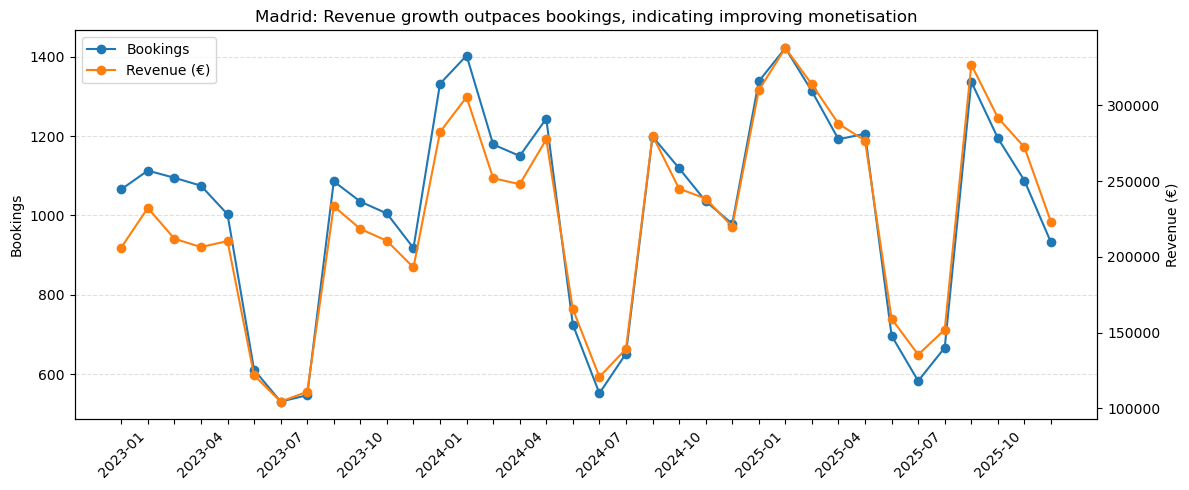

In [101]:
# Growth Overview
step = 3
months_short = [m[:7] for m in months]
months_display = [m if i % step == 0 else "" for i, m in enumerate(months_short)]

fig, ax1 = plt.subplots(figsize=(12, 5))

line1 = ax1.plot(months, bookings, marker="o", color="tab:blue", label="Bookings")
ax1.set_ylabel("Bookings", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
line2 = ax2.plot(months, revenue, marker="o", color="tab:orange", label="Revenue (€)")
ax2.set_ylabel("Revenue (€)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.set_xticks(range(len(months)))
ax1.set_xticklabels(months_display, rotation=45)

ax1.grid(axis="y", linestyle="--", alpha=0.4)

plt.title("Madrid: Revenue growth outpaces bookings, indicating improving monetisation")
plt.tight_layout()
plt.show()

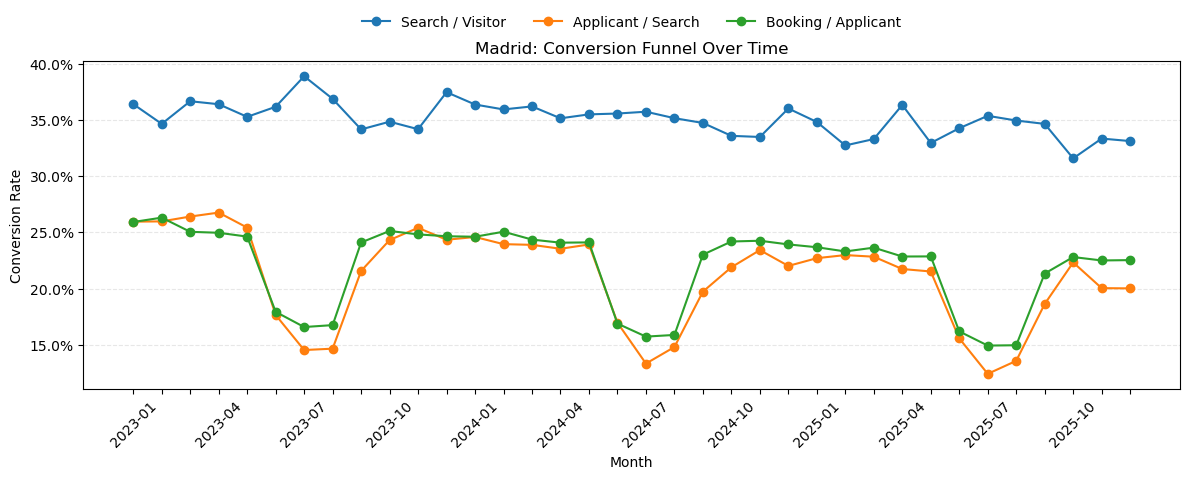

In [102]:
# Demand & Conversion Funnel

agg = defaultdict(lambda: {
    "visitors": 0,
    "searchers": 0,
    "applicants": 0,
    "bookings": 0
})

for r in data:
    month = r["month"]
    agg[month]["visitors"] += r["visitors"] or 0
    agg[month]["searchers"] += r["searchers"] or 0
    agg[month]["applicants"] += r["applicants"] or 0
    agg[month]["bookings"] += r["bookings"] or 0

months = sorted(agg.keys())

visitors = [agg[m]["visitors"] for m in months]
searchers = [agg[m]["searchers"] for m in months]
applicants = [agg[m]["applicants"] for m in months]
bookings = [agg[m]["bookings"] for m in months]

# Ratios
search_rate = [(s / v) if v else 0 for s, v in zip(searchers, visitors)]
application_rate = [(a / s) if s else 0 for a, s in zip(applicants, searchers)]
booking_rate = [(b / a) if a else 0 for b, a in zip(bookings, applicants)]

step = 3
months_display = [m if i % step == 0 else "" for i, m in enumerate(months_short)]

plt.figure(figsize=(12, 5))

plt.plot(months, search_rate, marker="o", label="Search / Visitor")
plt.plot(months, application_rate, marker="o", label="Applicant / Search")
plt.plot(months, booking_rate, marker="o", label="Booking / Applicant")

plt.xticks(range(len(months)), months_display, rotation=45)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.title("Madrid: Conversion Funnel Over Time")
plt.xlabel("Month")
plt.ylabel("Conversion Rate")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=3, frameon=False)

plt.tight_layout()
plt.show()

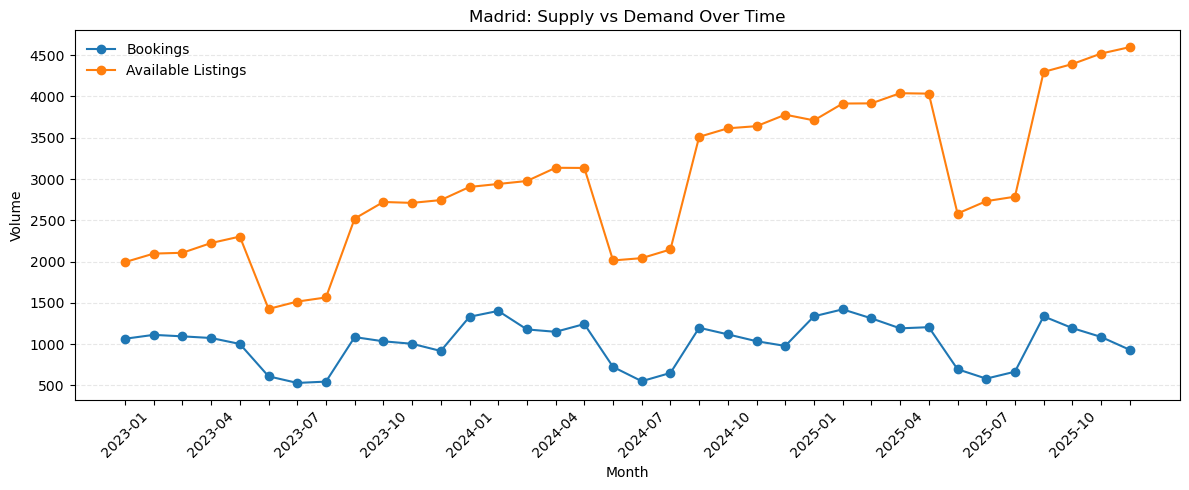

In [105]:
# Supply vs Demand
#To do bookings_per_listing = bookings / available_listings
agg = defaultdict(lambda: {
    "bookings": 0,
    "available_listings": 0,
    "created_listings": 0
})

for r in data:
    month = r["month"]
    agg[month]["bookings"] += r["bookings"] or 0
    agg[month]["available_listings"] += r["available_listings"] or 0
    agg[month]["created_listings"] += r["created_listings"] or 0

months = sorted(agg.keys())

bookings = [agg[m]["bookings"] for m in months]
available_listings = [agg[m]["available_listings"] for m in months]
created_listings = [agg[m]["created_listings"] for m in months]

bookings_per_listing = [
    (b / l) if l else 0
    for b, l in zip(bookings, available_listings)
]

months_short = [m[:7] for m in months]
step = 3
months_display = [m if i % step == 0 else "" for i, m in enumerate(months_short)]

plt.figure(figsize=(12, 5))

plt.plot(months, bookings, marker="o", label="Bookings")
plt.plot(months, available_listings, marker="o", label="Available Listings")

plt.xticks(range(len(months)), months_display, rotation=45)
plt.title("Madrid: Supply vs Demand Over Time")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend(loc="upper left", frameon=False)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

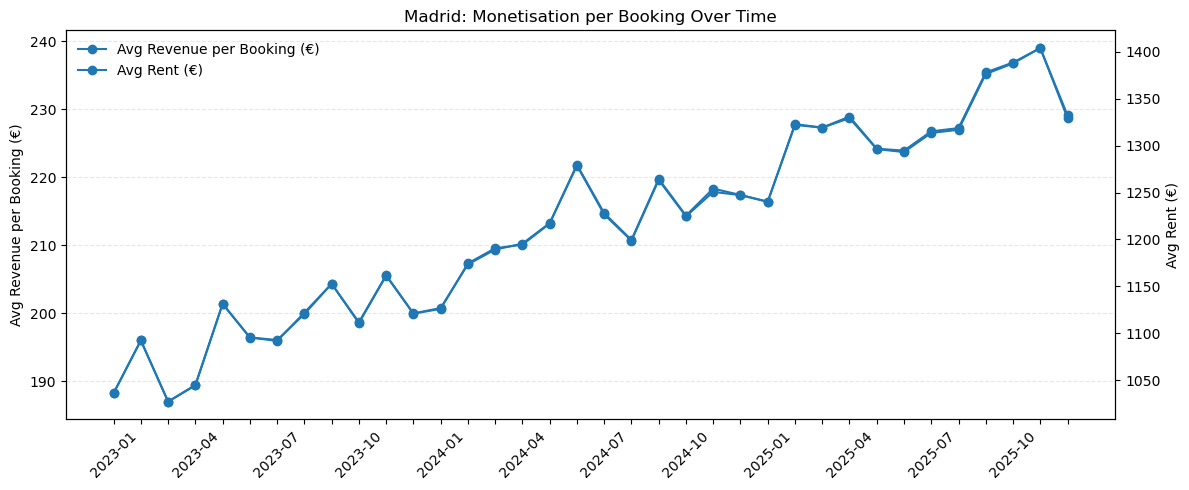

In [106]:
# Monetisation & Recommendations

agg = defaultdict(lambda: {
    "avg_revenue_per_booking_eur_sum": 0,
    "avg_rent_eur_sum": 0,
    "count": 0
})

for r in data:
    month = r["month"]
    agg[month]["avg_revenue_per_booking_eur_sum"] += r["avg_revenue_per_booking_eur"] or 0
    agg[month]["avg_rent_eur_sum"] += r["avg_rent_eur"] or 0
    agg[month]["count"] += 1

months = sorted(agg.keys())

avg_revenue_per_booking = [
    agg[m]["avg_revenue_per_booking_eur_sum"] / agg[m]["count"] if agg[m]["count"] else 0
    for m in months
]

avg_rent = [
    agg[m]["avg_rent_eur_sum"] / agg[m]["count"] if agg[m]["count"] else 0
    for m in months
]


months_short = [m[:7] for m in months]
step = 3
months_display = [m if i % step == 0 else "" for i, m in enumerate(months_short)]

fig, ax1 = plt.subplots(figsize=(12, 5))

line1 = ax1.plot(months, avg_revenue_per_booking, marker="o", label="Avg Revenue per Booking (€)")
ax1.set_ylabel("Avg Revenue per Booking (€)", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
line2 = ax2.plot(months, avg_rent, marker="o", label="Avg Rent (€)")
ax2.set_ylabel("Avg Rent (€)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=False)

ax1.set_xticks(range(len(months)))
ax1.set_xticklabels(months_display, rotation=45)

ax1.grid(axis="y", linestyle="--", alpha=0.3)
plt.title("Madrid: Monetisation per Booking Over Time")
plt.xlabel("Month")
plt.tight_layout()
plt.show()